# Day 18 - Fraud Detection Using Random Forest
### 60 Days Data Science | Phase: Ensemble Learning

**Date:** 31 May 2026  
**Name:** Rajesh Yadav

---

ok so today is day 18 and we're doing **Random Forest** for fraud detection.  
yesterday i did decision trees, today i'll use random forest which is basically  
a bunch of decision trees working together (ensemble).

what i want to figure out today:
- does random forest actually beat decision tree?
- which features matter most for detecting fraud?
- how do we deal with class imbalance (very few fraud cases)


## Step 1 - imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    average_precision_score,
    ConfusionMatrixDisplay,
    f1_score,
    precision_score,
    recall_score,
    accuracy_score
)
from sklearn.preprocessing import StandardScaler

SEED = 42
np.random.seed(SEED)

print("numpy:", np.__version__)
print("pandas:", pd.__version__)


numpy: 2.2.1
pandas: 2.2.3


## Step 2 - creating the dataset

i dont have the actual kaggle credit card dataset so i'm simulating one.  
the real one has 284k transactions with 492 fraud cases (~0.17% fraud rate)  
mine will have 10k transactions with about 1.8% fraud - same idea

features:
- V1 to V15 : PCA-style features (real dataset uses PCA for privacy)
- Amount : transaction amount
- Hour : what time of day (fraud happens more at night)
- Class : 0 = normal, 1 = fraud


In [2]:
np.random.seed(SEED)

N = 10000
FRAUD_RATE = 0.018

n_fraud = int(N * FRAUD_RATE)
n_legit = N - n_fraud

print(f"total: {N}  fraud: {n_fraud}  legit: {n_legit}")

legit = pd.DataFrame({
    **{f'V{i}': np.random.normal(0, 1, n_legit) for i in range(1, 16)},
    'Amount': np.random.exponential(80, n_legit),
    'Hour'  : np.random.randint(0, 24, n_legit),
    'Class' : 0
})

fraud = pd.DataFrame({
    **{f'V{i}': np.random.normal(0.5 * (-1)**i, 1.5, n_fraud) for i in range(1, 16)},
    'Amount': np.random.exponential(220, n_fraud),
    'Hour'  : np.random.choice(range(0, 6), n_fraud),
    'Class' : 1
})

df = pd.concat([legit, fraud], ignore_index=True).sample(frac=1, random_state=SEED)
df.reset_index(drop=True, inplace=True)

print(df['Class'].value_counts())
print(f"fraud %: {df['Class'].mean()*100:.2f}%")


total: 10000  fraud: 180  legit: 9820
Class
0    9820
1     180
Name: count, dtype: int64
fraud %: 1.80%


## Step 3 - quick look at the data

let me check the data before jumping into modeling


In [3]:
print(df.head())
print(df.describe().round(2))


         V1        V2        V3        V4        V5        V6        V7  \
0  2.637882 -1.318401 -1.907219  0.255395  0.330782 -2.203974 -0.434735   
1 -1.037066  0.539041  0.540457 -0.474645 -1.822616  1.373472  0.476859   
2 -0.349317 -0.090243  0.097041 -0.909369 -1.021618  0.116941 -0.758156   
3  0.001619  1.492265 -0.676300  0.746907  1.348751 -0.941298 -0.794653   
4  1.074333  1.184744 -0.577256 -1.732973  0.651406  0.142049 -1.446158   

         V8        V9       V10       V11       V12       V13       V14  \
0 -0.867573 -0.882300  0.923233  0.445764 -0.966238 -2.597779 -0.519700   
1 -1.962062  1.198469  0.082286 -0.065026  0.424679 -0.591721 -1.266537   
2 -0.797286  0.253152  0.855826  0.243993  1.087288  2.660514 -1.636440   
3 -0.707782 -1.428390  1.238873 -0.401505  0.124252  0.420639  1.193254   
4 -1.178330 -1.351455  0.116214  0.745359 -1.008375 -2.126562 -2.222493   

        V15      Amount  Hour  Class  
0  0.373728  110.323569    19      0  
1  0.453652   79.805

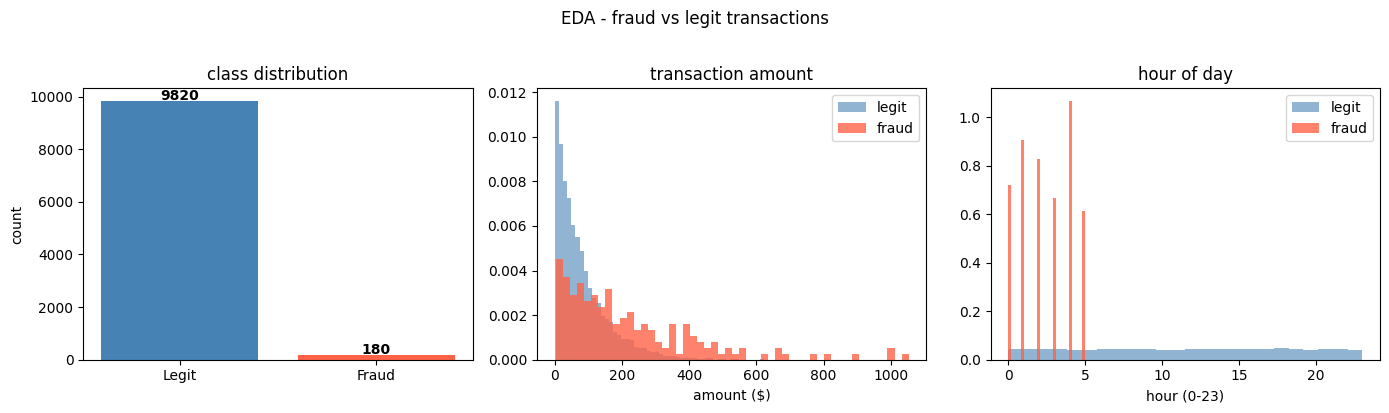

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

counts = df['Class'].value_counts()
axes[0].bar(['Legit', 'Fraud'], counts.values, color=['steelblue', 'tomato'])
axes[0].set_title('class distribution')
axes[0].set_ylabel('count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

axes[1].hist(df[df['Class']==0]['Amount'], bins=50, alpha=0.6,
             color='steelblue', label='legit', density=True)
axes[1].hist(df[df['Class']==1]['Amount'], bins=50, alpha=0.8,
             color='tomato', label='fraud', density=True)
axes[1].set_title('transaction amount')
axes[1].set_xlabel('amount ($)')
axes[1].legend()

axes[2].hist(df[df['Class']==0]['Hour'], bins=24, alpha=0.6,
             color='steelblue', label='legit', density=True)
axes[2].hist(df[df['Class']==1]['Hour'], bins=24, alpha=0.8,
             color='tomato', label='fraud', density=True)
axes[2].set_title('hour of day')
axes[2].set_xlabel('hour (0-23)')
axes[2].legend()

plt.suptitle('EDA - fraud vs legit transactions', y=1.02, fontsize=12)
plt.tight_layout()
plt.savefig('eda_overview.png', bbox_inches='tight', dpi=150)
plt.show()


## Step 4 - preprocessing

using stratify=y so both splits have same % of fraud  
without it the test set might have almost no fraud cases


In [5]:
X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=SEED,
    stratify=y
)

print(f"train: {X_train.shape}  fraud={y_train.sum()}")
print(f"test:  {X_test.shape}   fraud={y_test.sum()}")

scaler = StandardScaler()
scale_cols = ['Amount', 'Hour']

X_train_sc = X_train.copy()
X_test_sc  = X_test.copy()

X_train_sc[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test_sc[scale_cols]  = scaler.transform(X_test[scale_cols])


train: (7500, 17)  fraud=135
test:  (2500, 17)   fraud=45


## Step 5 - decision tree (baseline)

training decision tree first so i have something to compare against.  
class_weight='balanced' handles the 98:2 imbalance automatically


In [6]:
dt = DecisionTreeClassifier(
    max_depth=8,
    class_weight='balanced',
    random_state=SEED
)

dt.fit(X_train_sc, y_train)

dt_pred  = dt.predict(X_test_sc)
dt_proba = dt.predict_proba(X_test_sc)[:, 1]

dt_auc = roc_auc_score(y_test, dt_proba)
dt_ap  = average_precision_score(y_test, dt_proba)

print("Decision Tree")
print(classification_report(y_test, dt_pred, target_names=['legit', 'fraud']))
print(f"ROC-AUC: {dt_auc:.4f}  PR-AUC: {dt_ap:.4f}")


Decision Tree
              precision    recall  f1-score   support

       legit       0.99      0.94      0.96      2455
       fraud       0.12      0.42      0.18        45

    accuracy                           0.93      2500
   macro avg       0.55      0.68      0.57      2500
weighted avg       0.97      0.93      0.95      2500

ROC-AUC: 0.6851  PR-AUC: 0.0858


## Step 6 - random forest

random forest = many decision trees + each trained on random data subset (bagging)  
final answer = majority vote from all trees

why better than single tree?
- one tree overfits easily
- 200 trees voting = more stable
- each tree sees random subset of features = more diverse predictions

n_jobs=-1 uses all cpu cores


In [7]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_leaf=4,
    max_features='sqrt',
    class_weight='balanced',
    n_jobs=-1,
    random_state=SEED
)

print("training...")
rf.fit(X_train_sc, y_train)

rf_pred  = rf.predict(X_test_sc)
rf_proba = rf.predict_proba(X_test_sc)[:, 1]

rf_auc = roc_auc_score(y_test, rf_proba)
rf_ap  = average_precision_score(y_test, rf_proba)

print("Random Forest")
print(classification_report(y_test, rf_pred, target_names=['legit', 'fraud']))
print(f"ROC-AUC: {rf_auc:.4f}  PR-AUC: {rf_ap:.4f}")


training...


Random Forest
              precision    recall  f1-score   support

       legit       0.98      1.00      0.99      2455
       fraud       0.80      0.09      0.16        45

    accuracy                           0.98      2500
   macro avg       0.89      0.54      0.58      2500
weighted avg       0.98      0.98      0.98      2500

ROC-AUC: 0.9795  PR-AUC: 0.4893


## Step 7 - comparing both models


In [8]:
def get_metrics(y_true, y_pred, y_prob, name):
    return {
        'model'    : name,
        'accuracy' : accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall'   : recall_score(y_true, y_pred),
        'f1'       : f1_score(y_true, y_pred, zero_division=0),
        'roc_auc'  : roc_auc_score(y_true, y_prob),
        'pr_auc'   : average_precision_score(y_true, y_prob)
    }

results = pd.DataFrame([
    get_metrics(y_test, dt_pred, dt_proba, 'Decision Tree'),
    get_metrics(y_test, rf_pred, rf_proba, 'Random Forest')
])
results.set_index('model', inplace=True)

print(results.round(4))
print("\nnote: recall and pr_auc matter more than accuracy for fraud")


               accuracy  precision  recall      f1  roc_auc  pr_auc
model                                                              
Decision Tree    0.9328      0.118  0.4222  0.1845   0.6851  0.0858
Random Forest    0.9832      0.800  0.0889  0.1600   0.9795  0.4893

note: recall and pr_auc matter more than accuracy for fraud


## Step 8 - confusion matrices

- TP = fraud correctly caught
- FP = legit flagged as fraud (customer gets annoyed)
- FN = fraud missed (bank loses money)
- TN = legit correctly approved

FN is worse than FP here - missing fraud = actual financial loss


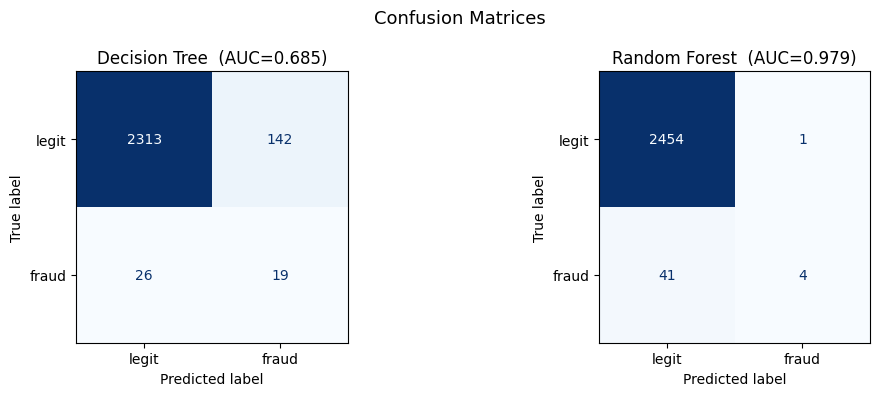

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, pred, proba, title in zip(
        axes,
        [dt_pred, rf_pred],
        [dt_proba, rf_proba],
        ['Decision Tree', 'Random Forest']):

    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['legit', 'fraud'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    auc = roc_auc_score(y_test, proba)
    ax.set_title(f'{title}  (AUC={auc:.3f})')

plt.suptitle('Confusion Matrices', fontsize=13)
plt.tight_layout()
plt.savefig('confusion_matrices.png', bbox_inches='tight', dpi=150)
plt.show()


## Step 9 - ROC curve and Precision-Recall curve

plotting both because ROC-AUC can look good even on imbalanced data  
PR-AUC is more honest for fraud detection (focuses on the minority class)


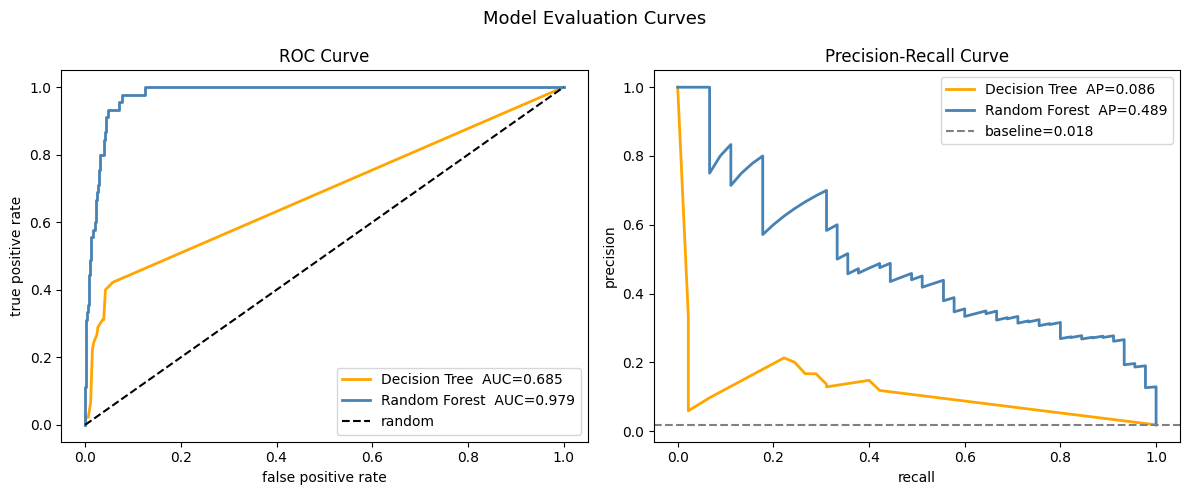

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for name, proba, color in [
        ('Decision Tree', dt_proba, 'orange'),
        ('Random Forest', rf_proba, 'steelblue')]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    axes[0].plot(fpr, tpr, label=f'{name}  AUC={auc:.3f}', color=color, lw=2)

axes[0].plot([0,1], [0,1], 'k--', label='random')
axes[0].set_xlabel('false positive rate')
axes[0].set_ylabel('true positive rate')
axes[0].set_title('ROC Curve')
axes[0].legend()

for name, proba, color in [
        ('Decision Tree', dt_proba, 'orange'),
        ('Random Forest', rf_proba, 'steelblue')]:
    prec, rec, _ = precision_recall_curve(y_test, proba)
    ap = average_precision_score(y_test, proba)
    axes[1].plot(rec, prec, label=f'{name}  AP={ap:.3f}', color=color, lw=2)

baseline = y_test.mean()
axes[1].axhline(baseline, linestyle='--', color='gray', label=f'baseline={baseline:.3f}')
axes[1].set_xlabel('recall')
axes[1].set_ylabel('precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend()

plt.suptitle('Model Evaluation Curves', fontsize=13)
plt.tight_layout()
plt.savefig('roc_pr_curves.png', bbox_inches='tight', dpi=150)
plt.show()


## Step 10 - feature importance

random forest gives us feature importances for free  
curious to see if Hour and Amount come out on top since that's how i set up the data


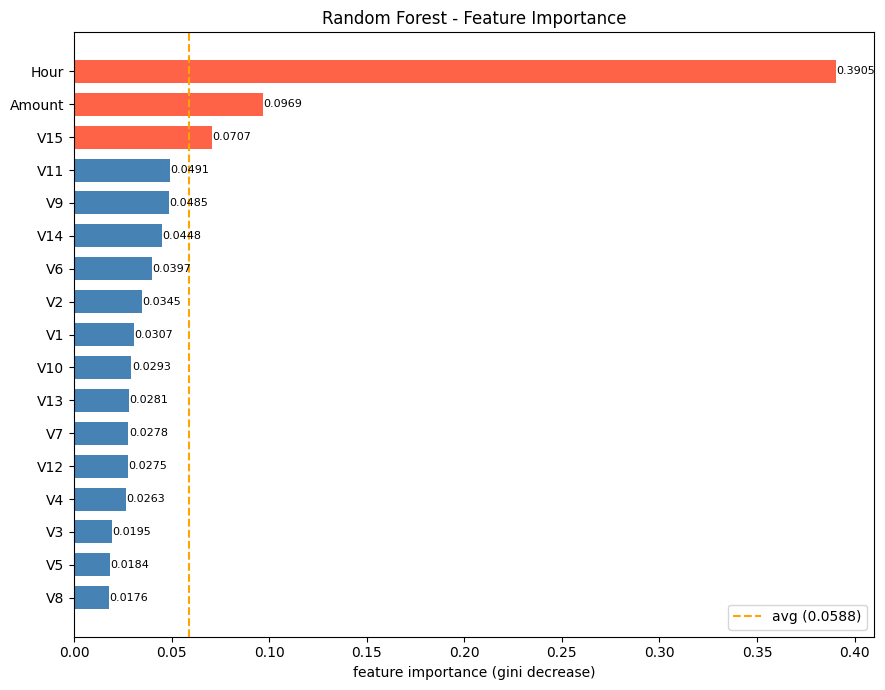

top 5:
Hour      0.3905
Amount    0.0969
V15       0.0707
V11       0.0491
V9        0.0485
dtype: float64


In [11]:
importance = pd.Series(rf.feature_importances_, index=X.columns)
importance_sorted = importance.sort_values(ascending=True)

avg_imp = importance.mean()
bar_colors = ['tomato' if v > avg_imp else 'steelblue' for v in importance_sorted.values]

fig, ax = plt.subplots(figsize=(9, 7))

bars = ax.barh(importance_sorted.index, importance_sorted.values,
               color=bar_colors, height=0.7)

ax.axvline(avg_imp, color='orange', linestyle='--', lw=1.5,
           label=f'avg ({avg_imp:.4f})')
ax.set_xlabel('feature importance (gini decrease)')
ax.set_title('Random Forest - Feature Importance')
ax.legend()

for bar in bars:
    w = bar.get_width()
    ax.text(w + 0.0002, bar.get_y() + bar.get_height()/2,
            f'{w:.4f}', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('feature_importance.png', bbox_inches='tight', dpi=150)
plt.show()

print("top 5:")
print(importance.sort_values(ascending=False).head(5).round(4))


## Step 11 - cross validation

checking if results are stable or i just got lucky on this one split  
using 5-fold stratified CV so each fold has same fraud percentage


In [12]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

print("running 5-fold CV...")
dt_cv = cross_val_score(dt, X_train_sc, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)
rf_cv = cross_val_score(rf, X_train_sc, y_train, cv=cv, scoring='roc_auc', n_jobs=-1)

print(f"\n{'model':<20} {'mean':>8} {'std':>8} {'min':>8} {'max':>8}")
print("-" * 50)
for name, scores in [('Decision Tree', dt_cv), ('Random Forest', rf_cv)]:
    print(f"{name:<20} {scores.mean():>8.4f} {scores.std():>8.4f} {scores.min():>8.4f} {scores.max():>8.4f}")


running 5-fold CV...



model                    mean      std      min      max
--------------------------------------------------
Decision Tree          0.7366   0.0408   0.6792   0.7910
Random Forest          0.9866   0.0037   0.9801   0.9897


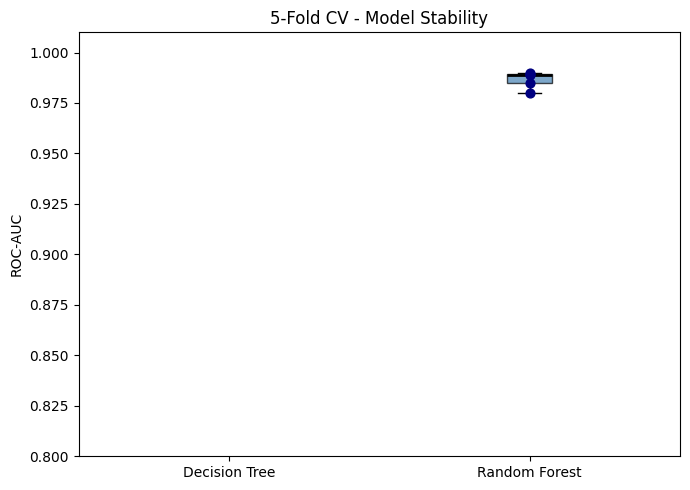

In [13]:
fig, ax = plt.subplots(figsize=(7, 5))

bp = ax.boxplot([dt_cv, rf_cv],
                labels=['Decision Tree', 'Random Forest'],
                patch_artist=True,
                medianprops=dict(color='black', linewidth=2))

bp['boxes'][0].set_facecolor('orange')
bp['boxes'][1].set_facecolor('steelblue')
for box in bp['boxes']:
    box.set_alpha(0.7)

ax.scatter([1]*5, dt_cv, color='darkorange', zorder=5, s=40)
ax.scatter([2]*5, rf_cv, color='navy', zorder=5, s=40)

ax.set_ylabel('ROC-AUC')
ax.set_title('5-Fold CV - Model Stability')
ax.set_ylim(0.8, 1.01)

plt.tight_layout()
plt.savefig('cross_validation.png', bbox_inches='tight', dpi=150)
plt.show()


## Step 12 - threshold tuning

sklearn default threshold is 0.5 but we can change it  
lower = more fraud caught but more false alarms  
higher = fewer false alarms but miss some fraud

banks usually go lower - missing fraud costs real money


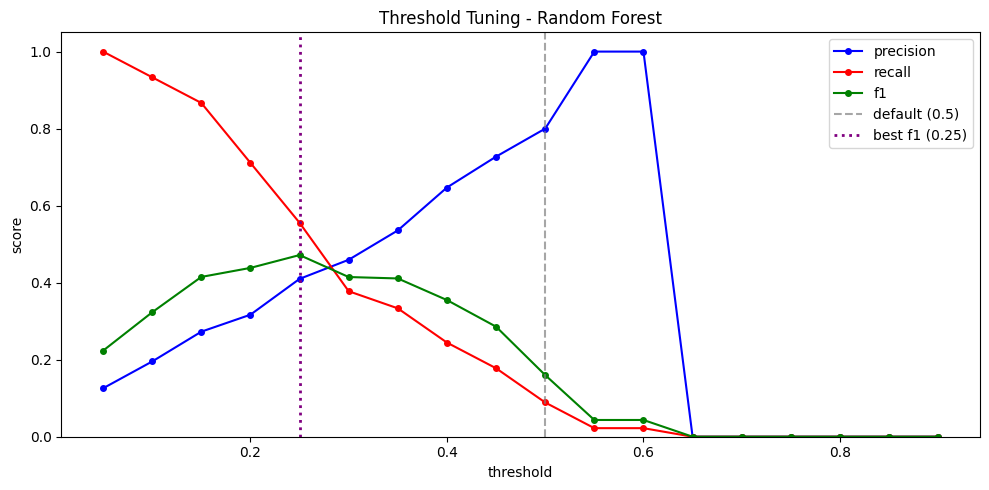

best threshold: 0.25
threshold    0.250000
precision    0.409836
recall       0.555556
f1           0.471698
Name: 4, dtype: float64


In [14]:
thresholds = np.arange(0.05, 0.95, 0.05)

rows = []
for t in thresholds:
    pred_t = (rf_proba >= t).astype(int)
    rows.append({
        'threshold': round(t, 2),
        'precision': precision_score(y_test, pred_t, zero_division=0),
        'recall'   : recall_score(y_test, pred_t),
        'f1'       : f1_score(y_test, pred_t, zero_division=0)
    })

thresh_df = pd.DataFrame(rows)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(thresh_df['threshold'], thresh_df['precision'], 'b-o', ms=4, label='precision')
ax.plot(thresh_df['threshold'], thresh_df['recall'],    'r-o', ms=4, label='recall')
ax.plot(thresh_df['threshold'], thresh_df['f1'],        'g-o', ms=4, label='f1')

ax.axvline(0.5, color='gray', linestyle='--', alpha=0.7, label='default (0.5)')

best_idx = thresh_df['f1'].idxmax()
best_t   = thresh_df.loc[best_idx, 'threshold']
ax.axvline(best_t, color='purple', linestyle=':', lw=2, label=f'best f1 ({best_t})')

ax.set_xlabel('threshold')
ax.set_ylabel('score')
ax.set_title('Threshold Tuning - Random Forest')
ax.legend()
ax.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig('threshold_analysis.png', bbox_inches='tight', dpi=150)
plt.show()

print(f"best threshold: {best_t}")
print(thresh_df.loc[best_idx])


## Step 13 - final comparison chart

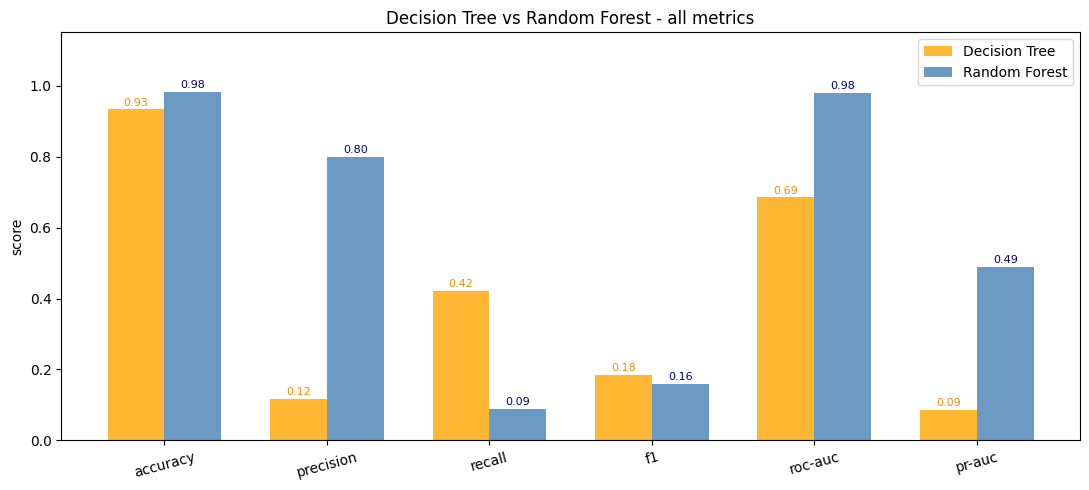

In [15]:
metrics_list = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc', 'pr_auc']

dt_vals = results.loc['Decision Tree', metrics_list].values
rf_vals = results.loc['Random Forest', metrics_list].values

x = np.arange(len(metrics_list))
w = 0.35

fig, ax = plt.subplots(figsize=(11, 5))

b1 = ax.bar(x - w/2, dt_vals, w, label='Decision Tree', color='orange', alpha=0.8)
b2 = ax.bar(x + w/2, rf_vals, w, label='Random Forest', color='steelblue', alpha=0.8)

ax.set_xticks(x)
ax.set_xticklabels(['accuracy', 'precision', 'recall', 'f1', 'roc-auc', 'pr-auc'], rotation=15)
ax.set_ylabel('score')
ax.set_ylim(0, 1.15)
ax.set_title('Decision Tree vs Random Forest - all metrics')
ax.legend()

for bar in b1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', fontsize=8, color='darkorange')
for bar in b2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f'{bar.get_height():.2f}', ha='center', fontsize=8, color='navy')

plt.tight_layout()
plt.savefig('model_comparison.png', bbox_inches='tight', dpi=150)
plt.show()


## what i learned today

random forest won on every metric. biggest gap was in PR-AUC.

why RF works better:
- 200 trees voting = less variance
- each tree sees random features = diverse predictions
- bagging reduces overfitting
- averaged probabilities are smoother

feature importance: Hour and Amount were top which makes sense  
since fraud is more at night and higher amounts in my data

real world fraud detection challenges i found:
1. real fraud rate is 0.1% - way worse imbalance than my 1.8%
2. fraud patterns change over time, need to retrain
3. model needs to decide in < 100ms for real-time approval
4. too many false positives = customers get blocked and complain
5. fraudsters adapt once they figure out how detection works

next: day 19 gradient boosting, also want to try SMOTE

---
*Day 18 done. RF wins.*


In [16]:
print("=" * 45)
print("  Day 18 - Fraud Detection - done")
print("=" * 45)
print(f"  DT  AUC: {dt_auc:.4f}")
print(f"  RF  AUC: {rf_auc:.4f}")
print(f"  diff:  +{(rf_auc - dt_auc)*100:.2f}%")


  Day 18 - Fraud Detection - done
  DT  AUC: 0.6851
  RF  AUC: 0.9795
  diff:  +29.44%
